# 五分

In [1]:
# %pip install matplotlib

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
import textwrap
from IPython.display import display
from IPython.display import Markdown
from datetime import datetime
import numpy_financial as npf
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast

# 依照評分 > 0(好) 隔天開盤買進，< 0(不好) 則賣出

In [3]:
# 計算一個公司的股票報酬率
def calculate_return(signal):
    # signal = [日期, 評分, 價格]
    hold = 0  # 持有的股數
    balance = 10000000
    init_balance = balance

    list_rtn = []

    for idx, item in enumerate(signal):
        if idx == len(signal) - 1:
            break
        score = float(item[1])
        price = float(signal[idx+1][2])

        if hold == 0:
            if score > 0:
                hold += int(balance/price)
                balance = 0
        elif hold > 0:
            if score < 0:
                balance += price*hold
                hold = 0
                
        list_rtn.append((balance + hold*price)/init_balance)
    
    balance += hold*price
    r = balance/init_balance

    return round(r, 5)

[1.054689, 1.0364730000000002, 0.992534, 1.0741349999999996, 1.180485, 0.9734959999999999, 0.975619, 0.9448970000000001, 1.1050280000000001, 1.114898, 1.1266399999999999, 1.144046, 1.089971, 1.093772, 1.032202, 0.986692, 1.076154, 1.008112, 1.0351430000000001, 1.050887, 1.046065, 1.0813739999999998, 1.1387450000000001, 1.02365, 1.3110009999999999, 1.0117129999999999, 1.051461, 1.134679, 1.004458, 1.085939, 0.9857989999999999, 1.050623, 1.0058639999999999, 1.134764, 0.9685010000000001, 1.131522, 1.0733450000000002, 1.10504, 1.0219580000000001, 1.112224, 1.141566, 1.1256289999999998, 0.9876339999999999, 1.0817489999999998, 0.9780260000000001, 1.058061, 0.9869720000000001, 1.1465830000000001, 1.156595, 1.005664, 1.056914, 1.0763559999999999, 1.019257, 1.113317, 1.153404, 1.079871, 1.036483, 1.0555020000000002, 1.254321]


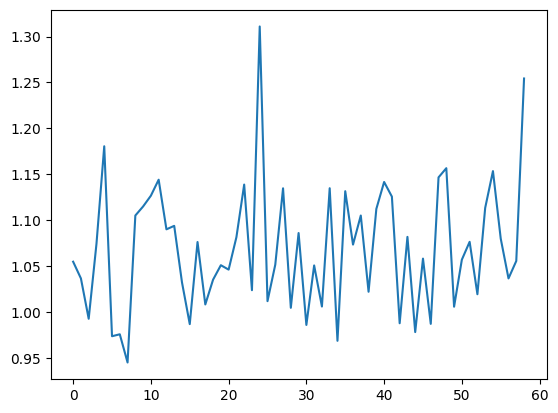

In [4]:
# 計算依照訊號操作的報酬率 依照評分在隔天開盤買進或賣出
rtn_avg = []
idx = 0
temp = 0

for i in range(1, 60):
    rtns = []
    eval_list = []

    with open("eval_gemini/output"+str(161+i), "r", encoding='utf-8') as f:
        data = f.read()
        eval_list = ast.literal_eval(data.split("原始數據")[1])

    # 跑每個公司的報酬率
    for list in eval_list:
        rtn = calculate_return(list)
        rtns.append(rtn)
    
    # if sum(rtns) / len(rtns) > temp:
    #     idx = i
    #     temp = sum(rtns) / len(rtns)
    rtn_avg.append(sum(rtns) / len(rtns))
# print(idx+ 161, idx)
plt.plot(rtn_avg)
print(rtn_avg)

# 計算隔天當沖準確率和期望值

In [5]:
# 計算隔天當沖（開盤買進收盤賣出or開盤賣出收盤回補）
def eval(signal, price):
    # [日期, 評分, 價格] , dataframe 股票價格
    tp = 0
    tn = 0
    fp = 0
    fn = 0
    rtns = []   # 記錄每天的報酬率

    for idx, item in enumerate(signal):
        score = float(item[1])
        index_location = price.index.get_loc(int(item[0]))  # 獲取特定索引的位置
        if index_location == len(price.index) - 1:
            break
        next_index = price.index[index_location + 1]  # 獲取下一個索引的位置
        next_row = price.loc[next_index]  # 找到下一個索引的列
        open = next_row['Open']
        close = next_row['Close']
        
        if score > 0:
            rtns.append(close/open)
            if close > open:
                tp += 1
            elif close < open:
                fp += 1
            else:   
                pass

        elif score < 0:
            # rtns.append(open/close)
            if close < open:
                tn += 1
            elif close > open:
                fn += 1
            else:   
                pass

    if len(rtns) == 0:
        return tp, tn, fp, fn, 1
    # 這檔股票的總報酬率
    total_rtn = 1.0 
    for i in range(len(rtns)):
        total_rtn *= rtns[i]
    return tp, tn, fp, fn, total_rtn

In [6]:
def ccl_acc_rtn(*args):
    ''' 
        start: 起始檔案編號
        end: 結束檔案編號
        計算從起始檔案到結束檔案的準確率和報酬率 
        回傳平均準確率和平均報酬率的list
    '''
    stock_ids = ["1101", "2211", "2385", "2542", "2880", "2912", "3023", "3264", "5269", "8027"]
    acc_list = [[], [], [], [], [], [], [], [], [], []]
    acc = []
    rtn_list = [[], [], [], [], [], [], [], [], [], []]
    rtn = []

    if len(args) == 1:
        # 如果只傳入一個參數，執行某些操作
        start = args[0]
        end = args[0] + 1
    elif len(args) == 2:
        # 如果傳入兩個參數，執行其他操作
        start = args[0]
        end = args[1]
    else:
        print("請傳入一個或兩個參數")

    for i in range(161 + start, 161 + end):
        with open("eval_gemini/output" + str(i), "r", encoding='utf-8') as f:
            data = f.read()
            eval_list = ast.literal_eval(data.split("原始數據")[1])

        for idx, list in enumerate(eval_list):
            dataframe = pd.read_csv(os.path.dirname(os.path.abspath(os.getcwd())) + "/price_history/" + stock_ids[idx] + "twse.csv", usecols=['Date', 'Open', 'Close'])
            dataframe.set_index('Date', inplace=True)  # 將'Date'行設置為索引
            tp, tn, fp, fn, rtn_l = eval(list, dataframe)
            acc_list[idx].append((tp+tn)/(tp+tn+fp+fn))
            rtn_list[idx].append(rtn_l)
            # print(f"{stock_ids[idx]} \ttp:{tp}, \ttn:{tn}, \tfp:{fp}, \tfn:{fn}, \tacc:{(tp+tn)/(tp+tn+fp+fn)}")

    for idx, acc_l in enumerate(acc_list):
        if len(acc_l) > 0:
            # print(f"{stock_ids[idx]} 平均準確率:{sum(acc) / len(acc)}")
            acc.append(sum(acc_l) / len(acc_l))
            rtn.append(sum(rtn_list[idx]) / len(rtn_list[idx]))
        else:
            acc.append(0)
            rtn.append(0)
    return acc, rtn

In [7]:
# 162 ~ 235 #非常好(2) #好(1) #無關(0) #不好(-1) #非常不好(-2)
stock_ids = ["1101", "2211", "2385", "2542", "2880", "2912", "3023", "3264", "5269", "8027"]

acc_1, rtn_1 = ccl_acc_rtn(1)
acc_2, rtn_2 = ccl_acc_rtn(9) #28
acc_3, rtn_3 = ccl_acc_rtn(18)
acc_4, rtn_4 = ccl_acc_rtn(28)

ev_1 = []
ev_2 = []
ev_3 = []
ev_4 = []

# 計算期望值
for i in range(len(stock_ids)):
    ev_1.append(acc_1[i] * rtn_1[i] - (1-acc_1[i]) * rtn_1[i])
    ev_2.append(acc_2[i] * rtn_2[i] - (1-acc_2[i]) * rtn_2[i])
    ev_3.append(acc_3[i] * rtn_3[i] - (1-acc_3[i]) * rtn_3[i])
    ev_4.append(acc_4[i] * rtn_4[i] - (1-acc_4[i]) * rtn_4[i])

# ==================== 繪製圖表 ====================
# 設置條形的位置和寬度
x = np.arange(len(stock_ids))  # the label locations
width = 0.35  # the width of the bars
fig, ax = plt.subplots(figsize=(10, 6))
# 繪製長條圖
bars1 = ax.bar(x - width/1.4, acc_1, width/2, label='1', color='skyblue')
bars2 = ax.bar(x - width/4, acc_2, width/2, label='9', color='green')
bars3 = ax.bar(x + width/4, acc_3, width/2, label='18', color='purple')
bars4 = ax.bar(x + width/1.4, acc_4, width/2, label='28', color='salmon')
# 添加標題和標籤
ax.set_xlabel('Stock ID')
ax.set_ylabel('Accuarcy')
ax.set_title('Comparison of Accuarcy')
ax.set_xticks(x)
ax.set_xticklabels(stock_ids)
ax.legend()
plt.tight_layout()
plt.show()



# 設置條形的位置和寬度
x = np.arange(len(stock_ids))  # the label locations
width = 0.35  # the width of the bars
fig, ax = plt.subplots(figsize=(10, 6))
# 繪製長條圖
bars1 = ax.bar(x - width/1.4, ev_1, width/2, label='1', color='skyblue')
bars2 = ax.bar(x - width/4, ev_2, width/2, label='9', color='green')
bars3 = ax.bar(x + width/4, ev_3, width/2, label='18', color='purple')
bars4 = ax.bar(x + width/1.4, ev_4, width/2, label='28', color='salmon')
# 添加標題和標籤
ax.set_xlabel('Stock ID')
ax.set_ylabel('Expected Value')
ax.set_title('Comparison of Expected Value')
ax.set_xticks(x)
ax.set_xticklabels(stock_ids)
ax.legend()
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/Users/yanyifu/Documents/_Coding/LLM Predict Stock/price_history/3264twse.csv'

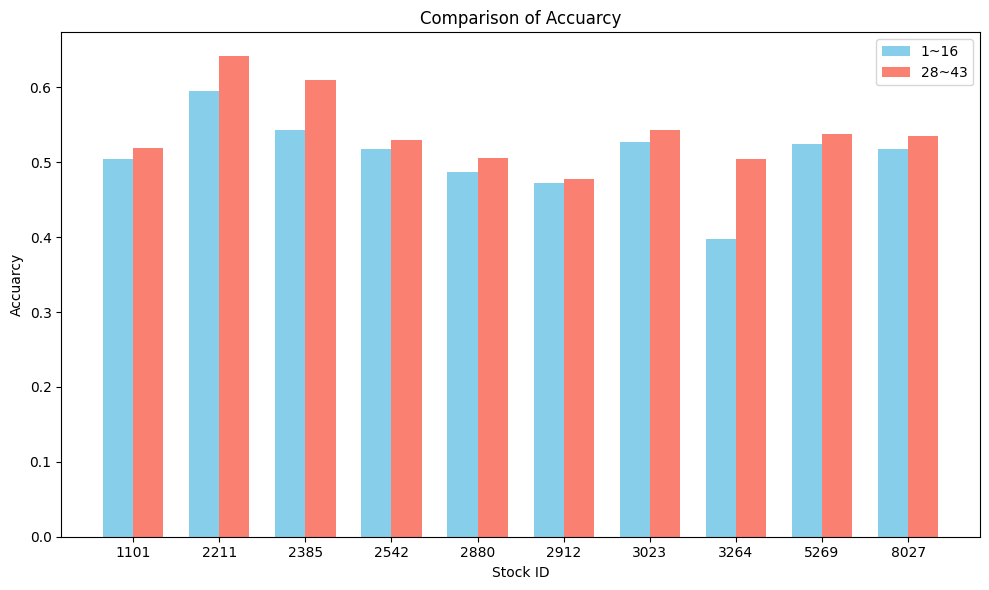

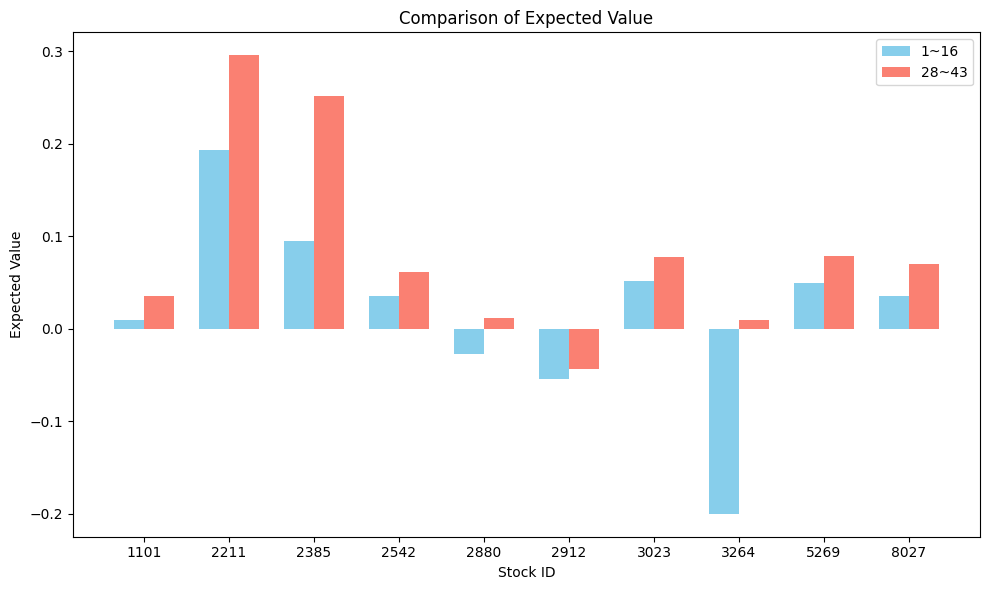

In [ ]:
# 變異後15次的報酬率
stock_ids = ["1101", "2211", "2385", "2542", "2880", "2912", "3023", "3264", "5269", "8027"]

acc_1, rtn_1 = ccl_acc_rtn(1, 1+15)
acc_2, rtn_2 = ccl_acc_rtn(28, 28+15) #28

# 畫期望值
ev_1 = []
ev_2 = []

for i in range(len(stock_ids)):
    ev_1.append(acc_1[i] * rtn_1[i] - (1-acc_1[i]) * rtn_1[i])
    ev_2.append(acc_2[i] * rtn_2[i] - (1-acc_2[i]) * rtn_2[i])

# ==================== 繪製圖表 ====================
# 設置條形的位置和寬度
x = np.arange(len(stock_ids))  # the label locations
width = 0.35  # the width of the bars
fig, ax = plt.subplots(figsize=(10, 6))
# 繪製長條圖
bars1 = ax.bar(x - width/2, acc_1, width, label='1~16', color='skyblue')
bars2 = ax.bar(x + width/2, acc_2, width, label='28~43', color='salmon')
# 添加標題和標籤
ax.set_xlabel('Stock ID')
ax.set_ylabel('Accuarcy')
ax.set_title('Comparison of Accuarcy')
ax.set_xticks(x)
ax.set_xticklabels(stock_ids)
ax.legend()
plt.tight_layout()
plt.show()


# 設置條形的位置和寬度
x = np.arange(len(stock_ids))  # the label locations
width = 0.35  # the width of the bars
fig, ax = plt.subplots(figsize=(10, 6))
# 繪製長條圖
bars1 = ax.bar(x - width/2, ev_1, width, label='1~16', color='skyblue')
bars2 = ax.bar(x + width/2, ev_2, width, label='28~43', color='salmon')
# 添加標題和標籤
ax.set_xlabel('Stock ID')
ax.set_ylabel('Expected Value')
ax.set_title('Comparison of Expected Value')
ax.set_xticks(x)
ax.set_xticklabels(stock_ids)
ax.legend()
plt.tight_layout()
plt.show()

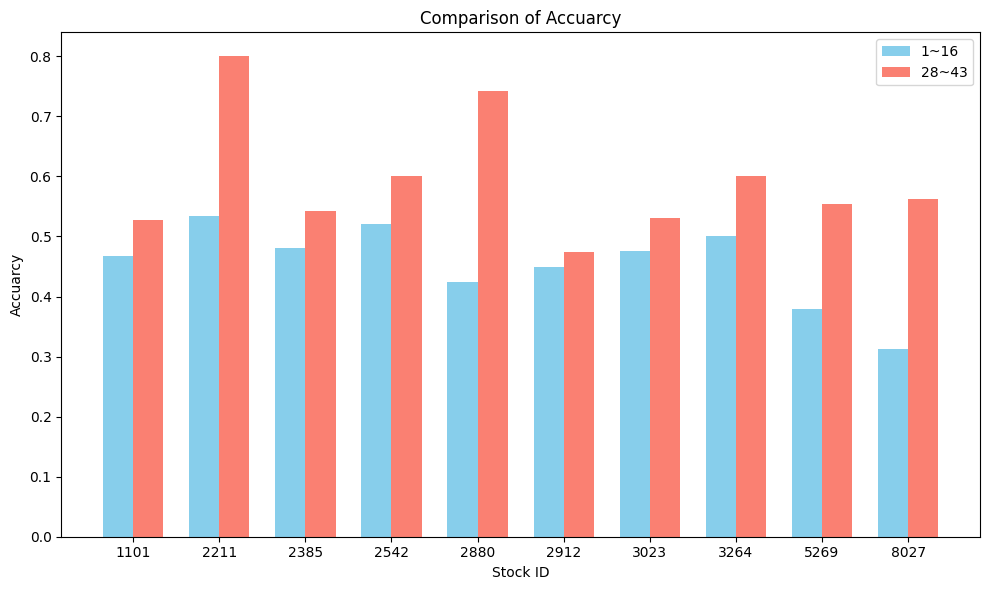

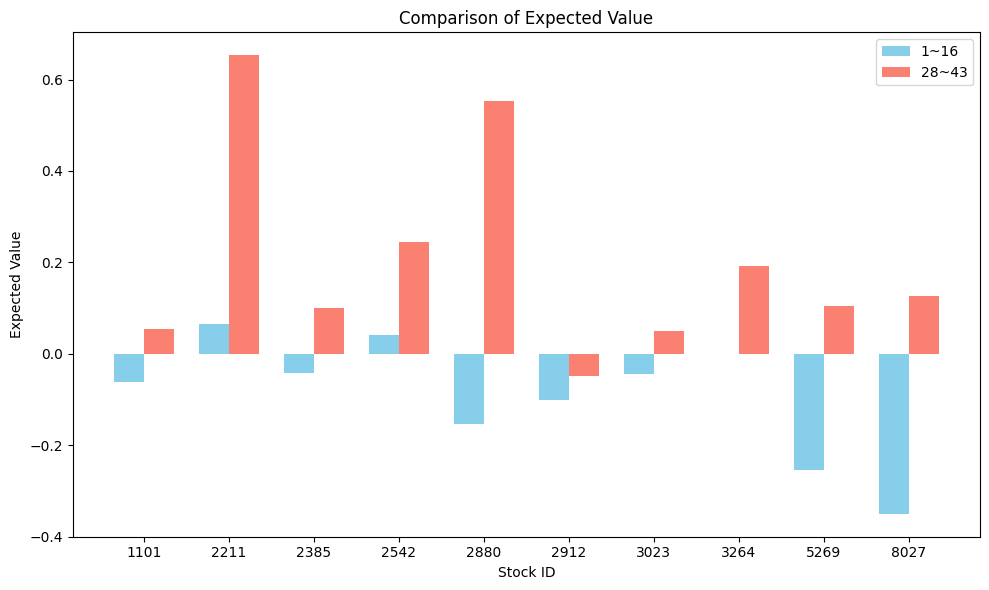

In [ ]:
# 變異後15次的報酬率
stock_ids = ["1101", "2211", "2385", "2542", "2880", "2912", "3023", "3264", "5269", "8027"]

acc_1, rtn_1 = ccl_acc_rtn(1)
acc_2, rtn_2 = ccl_acc_rtn(28) #28

# 畫期望值
ev_1 = []
ev_2 = []

for i in range(len(stock_ids)):
    ev_1.append(acc_1[i] * rtn_1[i] - (1-acc_1[i]) * rtn_1[i])
    ev_2.append(acc_2[i] * rtn_2[i] - (1-acc_2[i]) * rtn_2[i])

# ==================== 繪製圖表 ====================
# 設置條形的位置和寬度
x = np.arange(len(stock_ids))  # the label locations
width = 0.35  # the width of the bars
fig, ax = plt.subplots(figsize=(10, 6))
# 繪製長條圖
bars1 = ax.bar(x - width/2, acc_1, width, label='1~16', color='skyblue')
bars2 = ax.bar(x + width/2, acc_2, width, label='28~43', color='salmon')
# 添加標題和標籤
ax.set_xlabel('Stock ID')
ax.set_ylabel('Accuarcy')
ax.set_title('Comparison of Accuarcy')
ax.set_xticks(x)
ax.set_xticklabels(stock_ids)
ax.legend()
plt.tight_layout()
plt.show()


# 設置條形的位置和寬度
x = np.arange(len(stock_ids))  # the label locations
width = 0.35  # the width of the bars
fig, ax = plt.subplots(figsize=(10, 6))
# 繪製長條圖
bars1 = ax.bar(x - width/2, ev_1, width, label='1~16', color='skyblue')
bars2 = ax.bar(x + width/2, ev_2, width, label='28~43', color='salmon')
# 添加標題和標籤
ax.set_xlabel('Stock ID')
ax.set_ylabel('Expected Value')
ax.set_title('Comparison of Expected Value')
ax.set_xticks(x)
ax.set_xticklabels(stock_ids)
ax.legend()
plt.tight_layout()
plt.show()

10


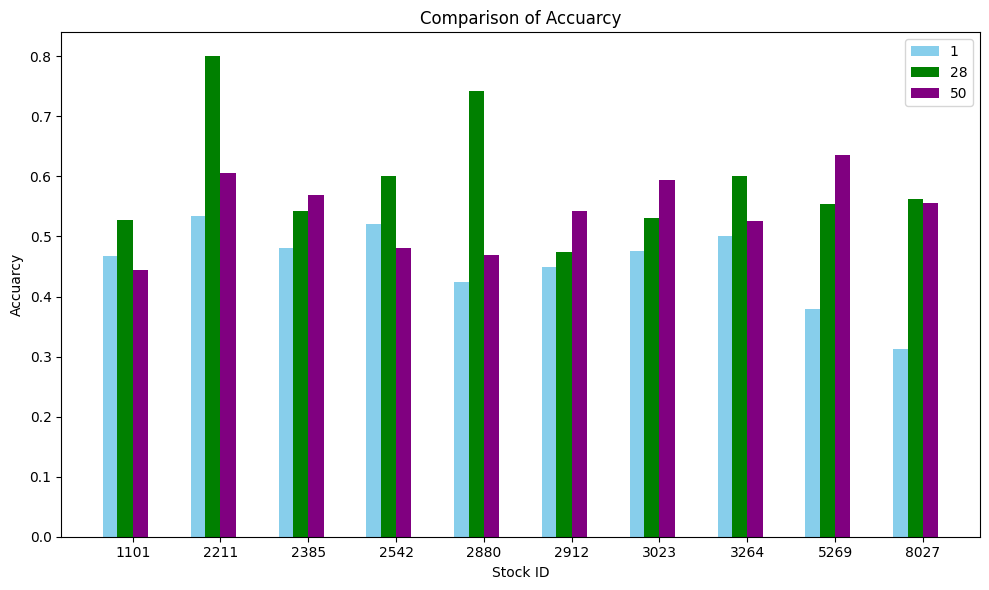

10


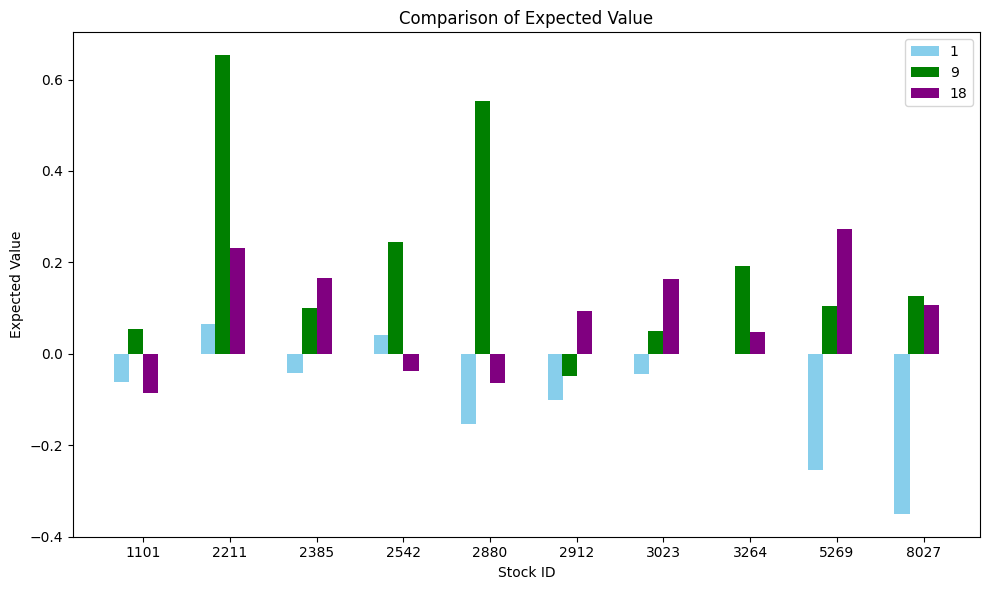

In [ ]:
# 157 ~ 235 #非常好(2) #好(1) #無關(0) #不好(-1) #非常不好(-2)
stock_ids = ["1101", "2211", "2385", "2542", "2880", "2912", "3023", "3264", "5269", "8027"]

acc_1, rtn_1 = ccl_acc_rtn(1)
acc_2, rtn_2 = ccl_acc_rtn(28) #28
acc_3, rtn_3 = ccl_acc_rtn(50)
# acc_4, rtn_4 = ccl_acc_rtn(60, 70)


count = 0
for i in range(10):
    if acc_1[i] < acc_2[i]:
        count += 1
print(count)

# 設置條形的位置和寬度
x = np.arange(len(stock_ids))  # the label locations
width = 0.35  # the width of the bars

# 設置圖表大小
fig, ax = plt.subplots(figsize=(10, 6))

# 繪製長條圖
bars1 = ax.bar(x - width/1.4, acc_1, width/2, label='1', color='skyblue')
bars2 = ax.bar(x - width/4, acc_2, width/2, label='28', color='green')
bars3 = ax.bar(x + width/4, acc_3, width/2, label='50', color='purple')
# bars4 = ax.bar(x + width/1.4, acc_4, width/2, label='50', color='salmon')


# 添加標題和標籤
ax.set_xlabel('Stock ID')
ax.set_ylabel('Accuarcy')
ax.set_title('Comparison of Accuarcy')
ax.set_xticks(x)
ax.set_xticklabels(stock_ids)
ax.legend()

# 顯示圖表
plt.tight_layout()
plt.show()

# 畫期望值 =============================================================
ev_1 = []
ev_2 = []
ev_3 = []
ev_4 = []


for i in range(len(stock_ids)):
    ev_1.append(acc_1[i] * rtn_1[i] - (1-acc_1[i]) * rtn_1[i])
    ev_2.append(acc_2[i] * rtn_2[i] - (1-acc_2[i]) * rtn_2[i])
    ev_3.append(acc_3[i] * rtn_3[i] - (1-acc_3[i]) * rtn_3[i])
    ev_4.append(acc_4[i] * rtn_4[i] - (1-acc_4[i]) * rtn_4[i])

count = 0
for i in range(10):
    if acc_1[i] < acc_2[i]:
        count += 1
print(count)

# 設置條形的位置和寬度
x = np.arange(len(stock_ids))  # the label locations
width = 0.35  # the width of the bars

# 設置圖表大小
fig, ax = plt.subplots(figsize=(10, 6))

# 繪製長條圖
bars1 = ax.bar(x - width/1.4, ev_1, width/2, label='1', color='skyblue')
bars2 = ax.bar(x - width/4, ev_2, width/2, label='9', color='green')
bars3 = ax.bar(x + width/4, ev_3, width/2, label='18', color='purple')
# bars4 = ax.bar(x + width/1.4, ev_4, width/2, label='18', color='salmon')


# 添加標題和標籤
ax.set_xlabel('Stock ID')
ax.set_ylabel('Expected Value')
ax.set_title('Comparison of Expected Value')
ax.set_xticks(x)
ax.set_xticklabels(stock_ids)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 當沖回測
# print(rtn_1)
# print(rtn_2)

# count = 0
# for i in range(10):
#     if rtn_1[i] < rtn_2[i]:
#         count += 1
# print("改善數 ",count)

# avg_rtn_1 = sum(rtn_1)/len(rtn_1)
# avg_rtn_2 = sum(rtn_2)/len(rtn_2)
# print(f'平均回策績效由{avg_rtn_1}提升到{avg_rtn_2}')

# # 設置條形的位置和寬度
# x = np.arange(len(stock_ids))  # the label locations
# width = 0.35  # the width of the bars

# # 設置圖表大小
# fig, ax = plt.subplots(figsize=(10, 6))

# # 繪製長條圖
# bars1 = ax.bar(x - width/2, rtn_1, width, label='Start', color='skyblue')
# bars2 = ax.bar(x + width/2, rtn_2, width, label='End', color='salmon')

# # 添加標題和標籤
# ax.set_xlabel('Stock ID')
# ax.set_ylabel('Expected Value')
# ax.set_title('Comparison of Expected Value')
# ax.set_xticks(x)
# ax.set_xticklabels(stock_ids)
# ax.legend()

# # 設置y軸的範圍
# ax.set_ylim([0.7, ax.get_ylim()[1]])

# # 顯示圖表
# plt.tight_layout()
# plt.show()